# Zepto Product Data Analysis

## 1. Import Libraries

In this project, we will use Python libraries to load, clean, analyze, and visualize the Zepto product dataset.

The main libraries used in this project are:

* **Pandas** — for loading and manipulating the dataset.
* **NumPy** — for numerical operations and data analysis.
* **Matplotlib** — for creating data visualizations.
* **Seaborn** — for creating statistical and analytical visualizations.

We begin by importing the libraries required for the analysis.


In [13]:
import pandas as pd

df = pd.read_csv("../data /sales_data.csv", encoding="cp1252")


## 3. Preview the Dataset

Before performing any analysis, we inspect the first few rows of the dataset.

This helps us understand the structure of the data, identify the available columns, and verify that the dataset has been loaded correctly.


In [15]:
df.head()


,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


## 4. Check Dataset Dimensions

We check the number of rows and columns in the dataset.

The number of rows represents the number of product records, while the number of columns represents the variables available for analysis.


In [16]:
df.shape


(3732, 9)

## 5. Check Column Names

We examine the column names to understand the variables available in the dataset.

Knowing the column names is important because they will be used throughout the data cleaning, analysis, and visualization stages.


In [17]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='str')

## 6. Understand the Dataset Structure

The `info()` method provides an overview of the dataset, including:

* Number of records
* Column names
* Data types
* Number of non-null values
* Memory usage

This helps us identify potential data-quality issues before beginning the cleaning process.


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Category                3732 non-null   str  
 1   name                    3732 non-null   str  
 2   mrp                     3732 non-null   int64
 3   discountPercent         3732 non-null   int64
 4   availableQuantity       3732 non-null   int64
 5   discountedSellingPrice  3732 non-null   int64
 6   weightInGms             3732 non-null   int64
 7   outOfStock              3732 non-null   bool 
 8   quantity                3732 non-null   int64
dtypes: bool(1), int64(6), str(2)
memory usage: 237.0 KB


In [20]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(2)

In [22]:
df[df.duplicated()]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


In [23]:
df[df.duplicated(keep=False)].sort_values("name")

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2908,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3252,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


## 9. Remove Exact Duplicate Records

The inspection showed that some rows were exact duplicates within the dataset.

Since these records contain identical information, we remove the duplicate rows to prevent them from affecting our analysis.

The cleaned DataFrame will retain only unique records.


In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000
mean,15680.482574,7.615818,4.007507,14193.206434,387.917694,213.251206
std,16093.113838,9.214038,2.203619,13854.430798,678.270812,194.781332
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,181.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [27]:
df[df["mrp"] == 0]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75


In [28]:
(df["mrp"] == 0).sum()

np.int64(1)

In [29]:
 df[df["discountedSellingPrice"] == 0]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75


In [30]:
(df["discountedSellingPrice"] == 0).sum()

np.int64(1)

In [31]:
df_clean = df[df["mrp"] > 0].copy()

In [32]:
df_clean.shape

(3729, 9)

In [33]:
df_clean["mrp"].min()

np.int64(1000)

## 10. Pricing Validation

Pricing is one of the key variables in this product dataset.

We will validate whether the `discountedSellingPrice` is consistent with the product's `mrp` and `discountPercent`.

The expected discounted price can be calculated using:

**Discounted Price = MRP × (1 − Discount Percentage / 100)**

This validation helps identify records where the stored selling price may not match the given MRP and discount percentage.


In [34]:
df_clean["calculatedSellingPrice"] = (
    df_clean["mrp"] *
    (1 - df_clean["discountPercent"] / 100)
).round(2)

## 11. Compare Actual and Calculated Prices

We now compare the original `discountedSellingPrice` with the price calculated from the MRP and discount percentage.

This allows us to determine whether the pricing information in the dataset is internally consistent.


In [35]:
df_clean[
    [
        "mrp",
        "discountPercent",
        "discountedSellingPrice",
        "calculatedSellingPrice"
    ]
].head(10)

,mrp,discountPercent,discountedSellingPrice,calculatedSellingPrice
0,2500,16,2100,2100.0
1,4200,16,3500,3528.0
2,5100,15,4300,4335.0
3,2000,15,1700,1700.0
4,1400,14,1200,1204.0
5,3500,17,2900,2905.0
6,7500,16,6300,6300.0
7,5800,15,4900,4930.0
8,2300,17,1900,1909.0
9,1900,15,1600,1615.0


## 13. Analyze Price Differences

We examine the statistical distribution of the price differences to understand how closely the recorded selling prices match the calculated prices.

This helps us determine whether the differences are small and likely related to rounding or whether further investigation is required.
|

In [39]:
df_clean["price_difference"] = (
    df_clean["discountedSellingPrice"]
    - df_clean["calculatedSellingPrice"]
).round(2)


In [40]:
df_clean["price_difference"].describe()


count    3729.000000
mean      -39.805578
std        79.233205
min      -822.000000
25%       -50.000000
50%        -2.000000
75%         0.000000
max         0.000000
Name: price_difference, dtype: float64

## 14. Investigate Pricing Differences

The pricing validation shows that the recorded discounted selling prices are generally slightly lower than the mathematically calculated prices.

This can occur because e-commerce platforms may apply their own pricing and rounding rules.

We will inspect the products with the largest differences to understand the pattern before deciding whether any further cleaning is required.


In [41]:
df_clean[
    [
        "name",
        "mrp",
        "discountPercent",
        "discountedSellingPrice",
        "calculatedSellingPrice",
        "price_difference"
    ]
].sort_values("price_difference").head(10)

,name,mrp,discountPercent,discountedSellingPrice,calculatedSellingPrice,price_difference
3367,Pampers Active Baby Diapers New Born Extra Small,109900,22,84900,85722.0,-822.0
3023,Pampers Active Baby Diapers New Born Extra Small,109900,22,84900,85722.0,-822.0
635,Dhara Kachi Ghani Mustard Oil Jar,125000,8,114300,115000.0,-700.0
121,Dhara Kachi Ghani Mustard Oil Jar,125000,8,114300,115000.0,-700.0
3556,Surf Excel Matic Top Load,72000,9,64900,65520.0,-620.0
3037,Gillette Mach 3 Turbo Cartridges,64900,10,57800,58410.0,-610.0
3381,Gillette Mach 3 Turbo Cartridges,64900,10,57800,58410.0,-610.0
114,Fortune Soyabean Oil,100500,0,99900,100500.0,-600.0
628,Fortune Soyabean Oil,100500,0,99900,100500.0,-600.0
2481,Pedigree Dog Food Adult Meat & Rice,66000,7,60800,61380.0,-580.0


## 15. Check for Missing Values

Missing values can affect calculations, visualizations, and statistical analysis.

We will check every column in the cleaned dataset to determine whether any product records contain missing information.

This will help us decide whether missing values need to be removed, replaced, or investigated further.


In [42]:
df_clean.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
calculatedSellingPrice    0
price_difference          0
dtype: int64

## 16. Calculate Missing Value Percentage

The number of missing values alone does not tell us how significant the problem is.

We calculate the percentage of missing values in each column relative to the total number of records.

This helps us understand the overall data quality and determine whether missing values could significantly affect our analysis.


In [43]:
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

missing_percentage.sort_values(ascending=False)

Category                  0.0
name                      0.0
mrp                       0.0
discountPercent           0.0
availableQuantity         0.0
discountedSellingPrice    0.0
weightInGms               0.0
outOfStock                0.0
quantity                  0.0
calculatedSellingPrice    0.0
price_difference          0.0
dtype: float64

## 17. Check Data Types

Different types of analysis require appropriate data types.

For example:

* Prices should be numerical.
* Discount percentages should be numerical.
* Product names and categories should be text.
* Stock availability should be represented as a Boolean value.

We inspect the current data types to identify any columns that may require conversion or further cleaning.


In [44]:
df_clean.dtypes


Category                      str
name                          str
mrp                         int64
discountPercent             int64
availableQuantity           int64
discountedSellingPrice      int64
weightInGms                 int64
outOfStock                   bool
quantity                    int64
calculatedSellingPrice    float64
price_difference          float64
dtype: object

## 18. Explore Product Categories

Product categories help us understand how the product catalog is distributed across different types of products.

We will first identify the number of unique categories and then examine how many products belong to each category.

This can help us understand which product categories have the largest representation in the dataset.


In [45]:
df_clean["Category"].nunique()

14

## 19. Count Products by Category

We now calculate the number of products available in each category.

This allows us to compare the size of different product categories within the catalog.


In [46]:
category_counts = (
    df_clean["Category"]
    .value_counts()
)

category_counts

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          193
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

## 20. Identify the Largest Product Categories

To make the category distribution easier to analyze, we will identify the categories containing the highest number of products.

This can help highlight the areas where the product catalog has the greatest variety.


In [47]:
category_counts.head(10)

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          193
Biscuits                 147
Dairy, Bread & Batter    129
Name: count, dtype: int64

## 21. Visualize Product Categories

A visualization makes it easier to compare the number of products across categories.

We will create a bar chart showing the 10 categories with the highest number of products.


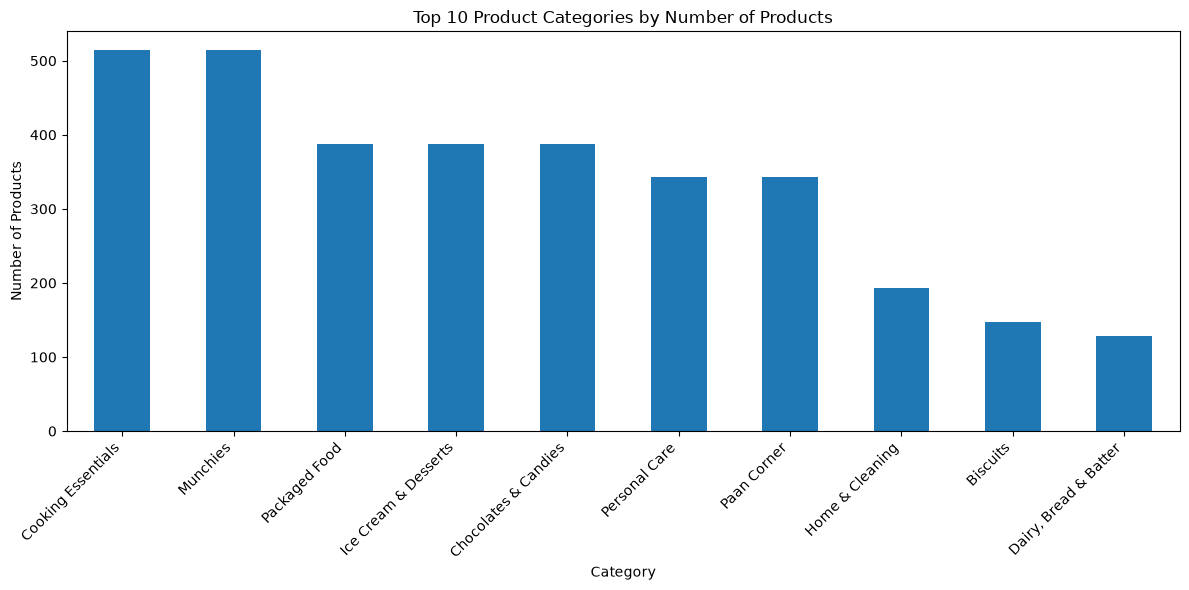

In [48]:
plt.figure(figsize=(12, 6))

category_counts.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Number of Products")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 22. Analyze MRP Distribution

The MRP variable represents the listed price of a product.

We will examine its statistical distribution to understand the range of product prices and identify potentially unusual values.

Understanding the distribution of prices will help us perform further pricing analysis.


In [49]:
df_clean["mrp"].describe()

count      3729.000000
mean      15684.687584
std       16093.222553
min        1000.000000
25%        6000.000000
50%       11000.000000
75%       20000.000000
max      260000.000000
Name: mrp, dtype: float64

## 23. Visualize MRP Distribution

Summary statistics provide numerical information about product prices, but a visualization can help us understand the overall shape of the price distribution.

We will use a histogram to see how product MRP values are distributed across different price ranges.


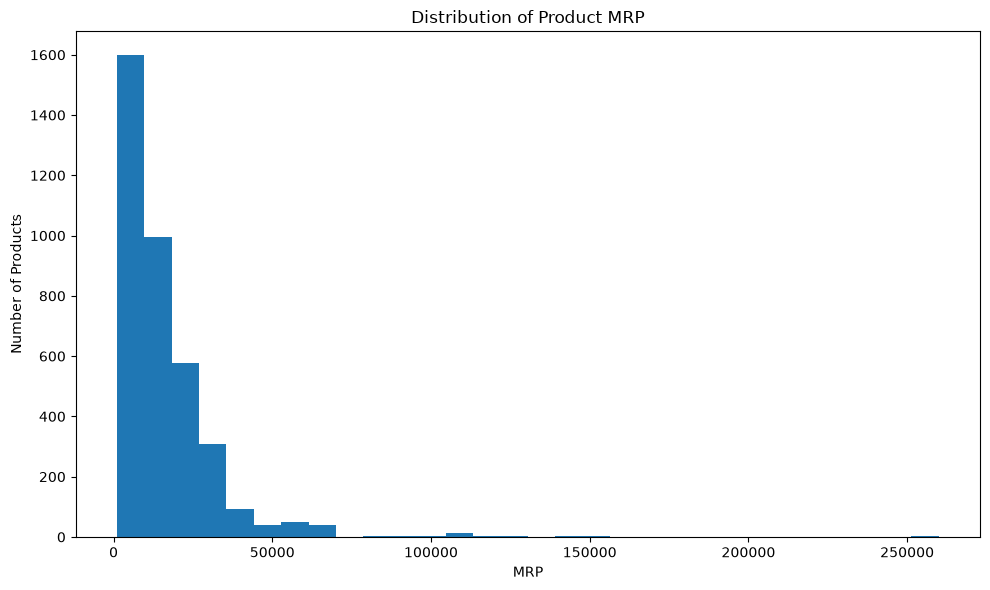

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["mrp"], bins=30)

plt.title("Distribution of Product MRP")
plt.xlabel("MRP")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## 24. Analyze Discount Distribution

Discount percentage is an important variable for understanding the pricing structure of the product catalog.

We will examine the statistical distribution of discounts to understand the typical discount levels and their overall range.


In [51]:


df_clean["discountPercent"].describe()

count    3729.000000
mean        7.617860
std         9.214429
min         0.000000
25%         0.000000
50%         6.000000
75%        10.000000
max        51.000000
Name: discountPercent, dtype: float64

In [52]:
discount_counts = (
    df_clean["discountPercent"]
    .value_counts()
    .sort_index()
)

discount_counts

discountPercent
0     1177
1       44
2      186
3       86
4      122
5      226
6      213
7      127
8       69
9      201
10     466
11      69
12      43
13      39
14      61
15     125
16      58
17      49
18      21
19       1
20     113
21       7
22      13
23       1
24       6
25      28
26      15
27       5
28       8
29       7
30      56
31       2
32       2
33       2
35       2
40      10
43       4
45       2
46       2
49       3
50      55
51       3
Name: count, dtype: int64

## 26. Visualize Discount Distribution

We will create a bar chart showing the number of products associated with each discount percentage.

This visualization allows us to easily identify the most common discount levels in the product catalog.



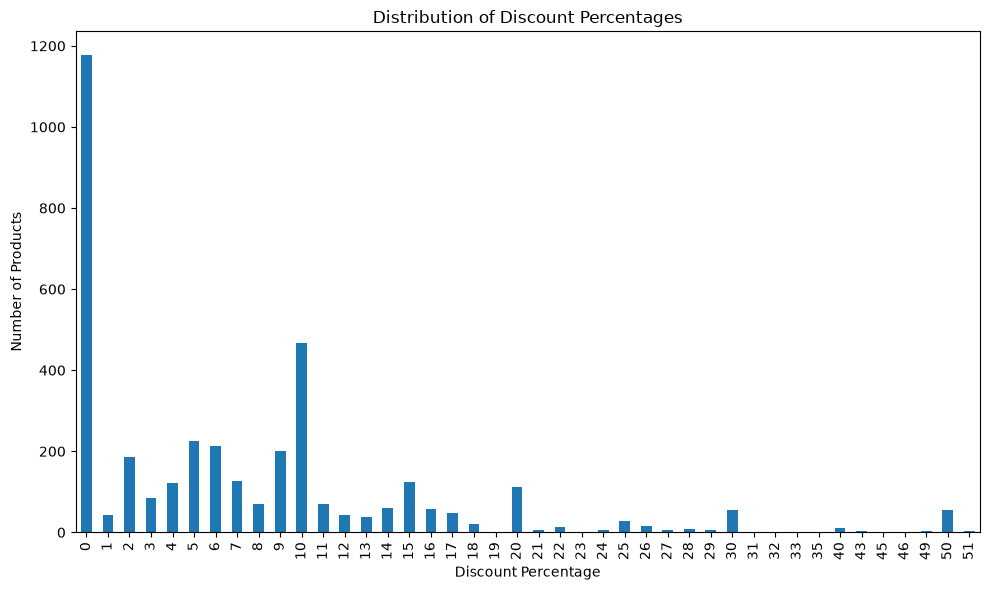

In [54]:
plt.figure(figsize=(10, 6))

discount_counts.plot(kind="bar")

plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [ ]:
ßß